In [2]:
import os
import matplotlib.pyplot as plt

In [3]:
def read_result_file(file_path):
    with open(file_path, 'r') as f:
        results = f.readlines()

    result_dict = dict()
    k=0
    for l in results:
        l = l.strip()

        if l.strip() == 'S':
            embedding = 'S'
            result_dict[embedding] = dict()
        elif l.strip() == 'F':
            embedding = 'F'
            result_dict[embedding] = dict()
        elif l.strip() == 'FA':
            embedding = 'FA'
            result_dict[embedding] = dict()
        elif l.strip().startswith('k='):
            k = int(l[2:])
            result_dict[embedding][k] = {}
        elif l.strip().startswith('Best Epoch'):
            result_dict[embedding][k]['best_epoch'] = int(l.strip().split()[-1])
        elif l.strip().startswith('Baseline Accuracy'):
            result_dict[embedding][k]['baseline_acc'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Confidence AUC'):
            result_dict[embedding][k]['confidence_auc'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Confidence AUPR'):
            result_dict[embedding][k]['confidence_aupr'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Confidence FPR@95'):
            result_dict[embedding][k]['confidence_fpr@95'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Confidence Accuracy'):
            result_dict[embedding][k]['confidence_acc'] = float(l.strip().split()[-1])
            result_dict[embedding][k]['best_threshold'] = float(l.strip().split('=')[1].split(')')[0])
        elif l.strip().startswith('Test Accuracy'):
            result_dict[embedding][k]['accuracy'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test ROC-AUC'):
            result_dict[embedding][k]['auc'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test AUPR'):
            result_dict[embedding][k]['aupr'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test FPR@95'):
            result_dict[embedding][k]['fpr@95'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test Precision'):
            result_dict[embedding][k]['precision'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test recall'):
            result_dict[embedding][k]['recall'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test NPV'):
            result_dict[embedding][k]['npv'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test Specificity'):
            result_dict[embedding][k]['specificity'] = float(l.strip().split()[-1])

    return result_dict

In [4]:
"""
result_dict should be formatted:
{
    'label1': [1, 2, 3, 4, 5, 6, 7, 8],
    'label2': [2, 3, 4, 5, 6, 7, 8, 9],
    ...,
    'labeln': [n, ..., n]
}
If want to draw baseline line with the same color to other label, the label of baseline should be 'baseline_{the other label}'
"""

def draw_graph(result_dict, x, xlabel, ylabel, title, save_figure, save_dir=None):
    colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5'
]
    color_match_dict = {}
    color_idx = 0

    plt.figure(figsize=(10, 6))
    for label, values in result_dict.items():
        if 'baseline' in label:
            suffix = '_'.join(label.split('_')[1:])
            if suffix in color_match_dict:
                color = color_match_dict[suffix]
            else:
                color = colors[color_idx]
                color_idx += 1
                if suffix:
                    color_match_dict[suffix] = color
            plt.plot(x, values, linestyle='--', color=color, label=label)
        elif 'confidence' in label:
            suffix = '_'.join(label.split('_')[1:])
            if suffix in color_match_dict:
                color = color_match_dict[suffix]
            else:
                color = colors[color_idx]
                color_idx += 1
                if suffix:
                    color_match_dict[suffix] = color
            plt.plot(x, values, linestyle=':', color=color, label=label)
        else:
            if label in color_match_dict:
                color = color_match_dict[label]
            else:
                color = colors[color_idx]
                color_idx += 1
                color_match_dict[label] = color
            plt.plot(x, values, linestyle = '-', color = color, label=label)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    if save_figure:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, f'{title}.png'))
    plt.close()

### nhot_normal, compare similarity criteria

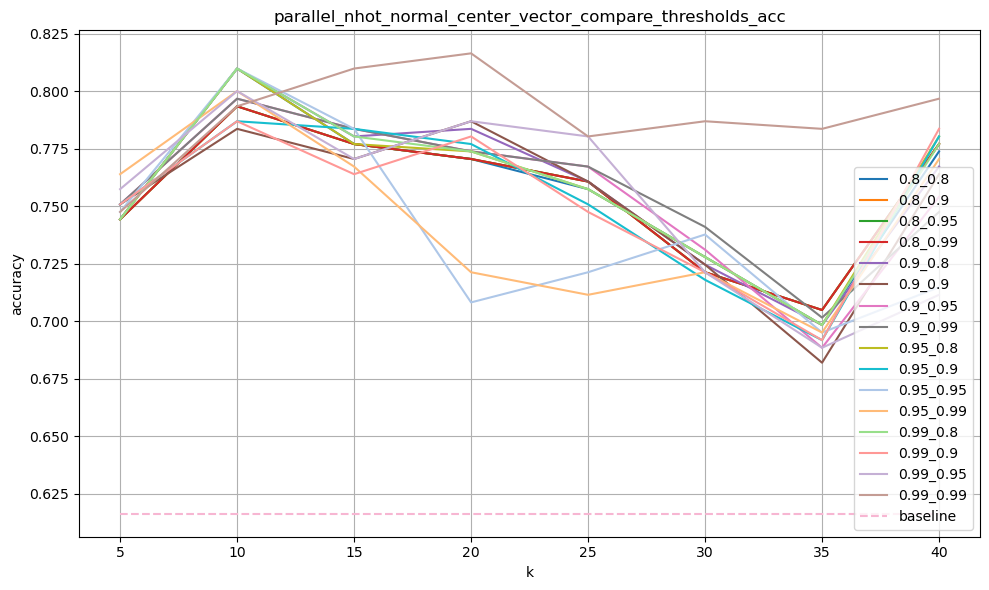

In [5]:
# Accuracy

thresholds = [0.8, 0.9, 0.95, 0.99]
merge_thresholds = [0.8, 0.9, 0.95, 0.99]
ks = [5, 10, 15, 20, 25, 30, 35, 40]
result_dict = {}

for t in thresholds:
    for mt in merge_thresholds:
        result_file = f'./parallel/nhot_normal/center_vector/{t}_{mt}/label_criteria_1/result.txt'

        raw_result_file = read_result_file(result_file)
        result_dict[f'{t}_{mt}'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]
result_dict['baseline'] = [raw_result_file['FA'][5]['baseline_acc']]*len(ks)

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_nhot_normal_center_vector_compare_thresholds_acc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


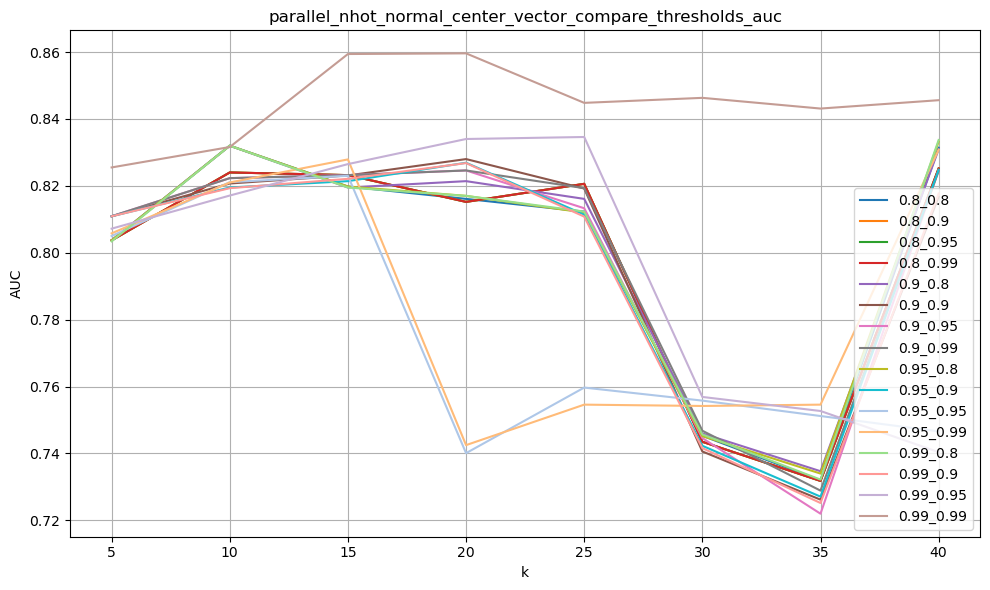

In [6]:
# AUC

thresholds = [0.8, 0.9, 0.95, 0.99]
merge_thresholds = [0.8, 0.9, 0.95, 0.99]
ks = [5, 10, 15, 20, 25, 30, 35, 40]
result_dict = {}

for t in thresholds:
    for mt in merge_thresholds:
        result_file = f'./parallel/nhot_normal/center_vector/{t}_{mt}/label_criteria_1/result.txt'

        raw_result_file = read_result_file(result_file)
        result_dict[f'{t}_{mt}'] = [raw_result_file['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_nhot_normal_center_vector_compare_thresholds_auc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


### normal, compare similarity criteria

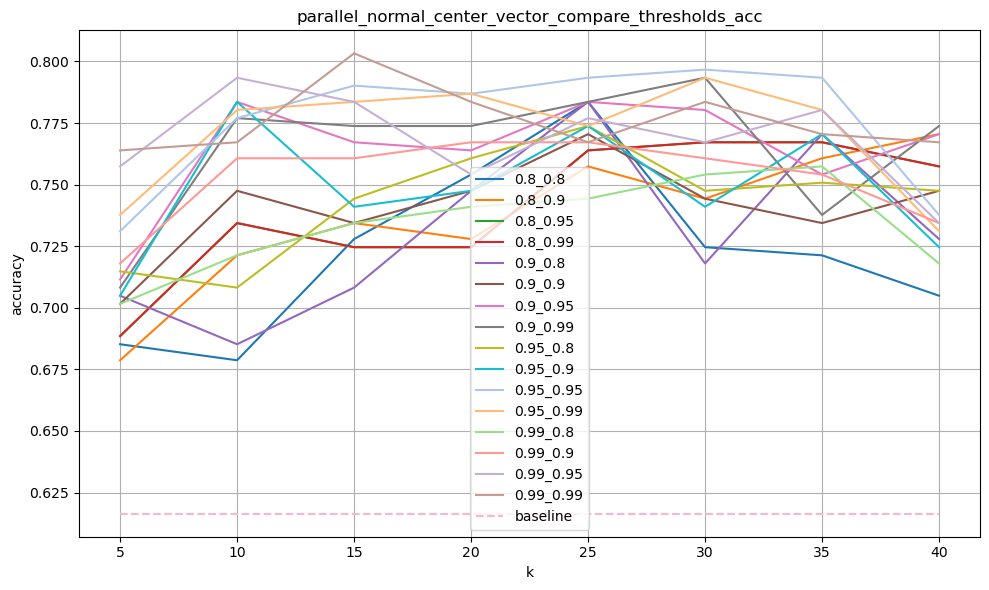

In [7]:
# Accuracy

thresholds = [0.8, 0.9, 0.95, 0.99]
merge_thresholds = [0.8, 0.9, 0.95, 0.99]
ks = [5, 10, 15, 20, 25, 30, 35, 40]
result_dict = {}

for t in thresholds:
    for mt in merge_thresholds:
        result_file = f'./parallel/normal/center_vector/{t}_{mt}/label_criteria_1/result.txt'

        raw_result_file = read_result_file(result_file)
        result_dict[f'{t}_{mt}'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]
result_dict['baseline'] = [raw_result_file['FA'][5]['baseline_acc']]*len(ks)

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_normal_center_vector_compare_thresholds_acc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


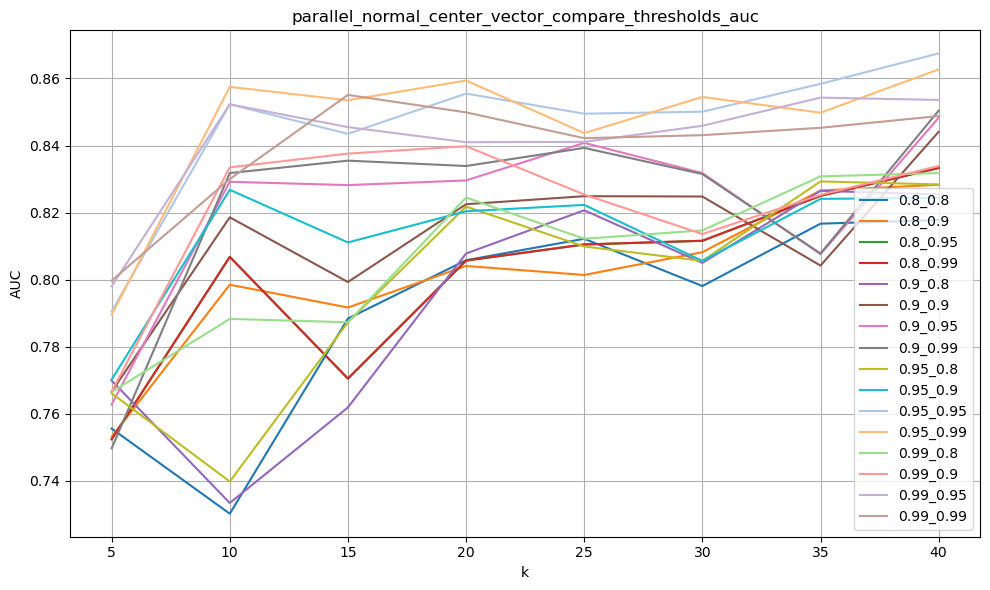

In [8]:
# AUC

thresholds = [0.8, 0.9, 0.95, 0.99]
merge_thresholds = [0.8, 0.9, 0.95, 0.99]
ks = [5, 10, 15, 20, 25, 30, 35, 40]
result_dict = {}

for t in thresholds:
    for mt in merge_thresholds:
        result_file = f'./parallel/normal/center_vector/{t}_{mt}/label_criteria_1/result.txt'

        raw_result_file = read_result_file(result_file)
        result_dict[f'{t}_{mt}'] = [raw_result_file['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_normal_center_vector_compare_thresholds_auc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


### nhot_normal vs. normal

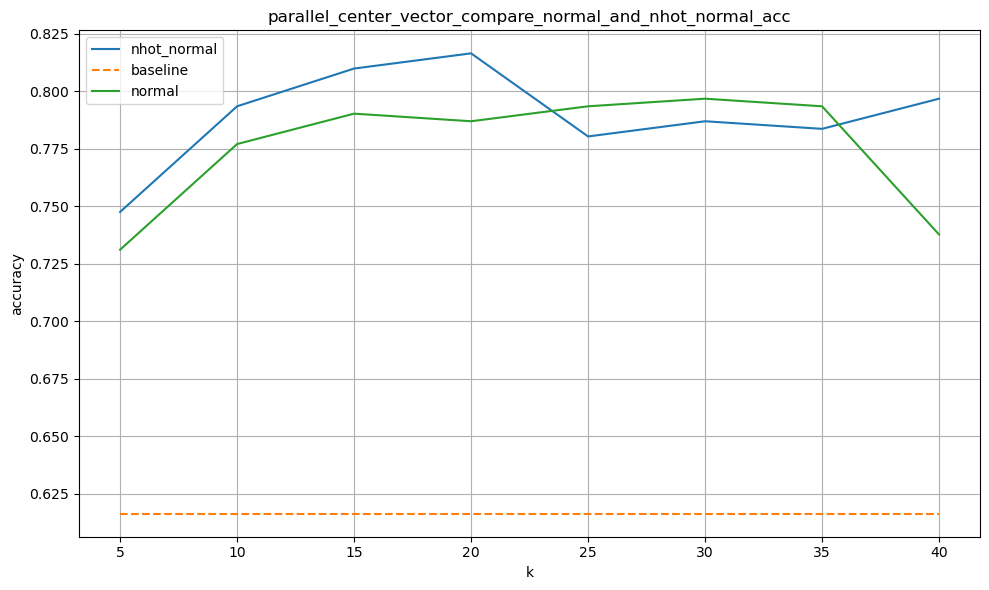

In [9]:
# Accuracy
result_dict = {}
result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['nhot_normal'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]
result_dict['baseline'] = [raw_result_file['FA'][5]['baseline_acc']]*len(ks)

result_file = f'./parallel/normal/center_vector/0.95_0.95/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['normal'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_center_vector_compare_normal_and_nhot_normal_acc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


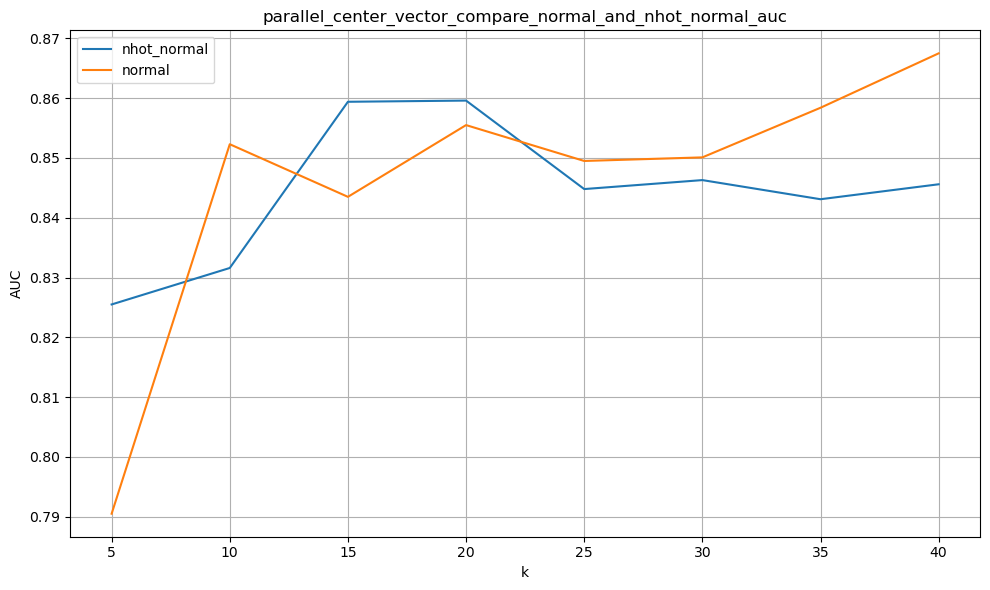

In [10]:
# AUC
result_dict = {}
result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['nhot_normal'] = [raw_result_file['FA'][k]['auc'] for k in ks]

result_file = f'./parallel/normal/center_vector/0.95_0.95/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['normal'] = [raw_result_file['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_center_vector_compare_normal_and_nhot_normal_auc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


### Node embedding: center vector vs . central vector
* center vector: cluster 내 노드 임베딩의 평균 값
* central vector: cluster 중심과 가장 가까운 노드의 임베딩 값

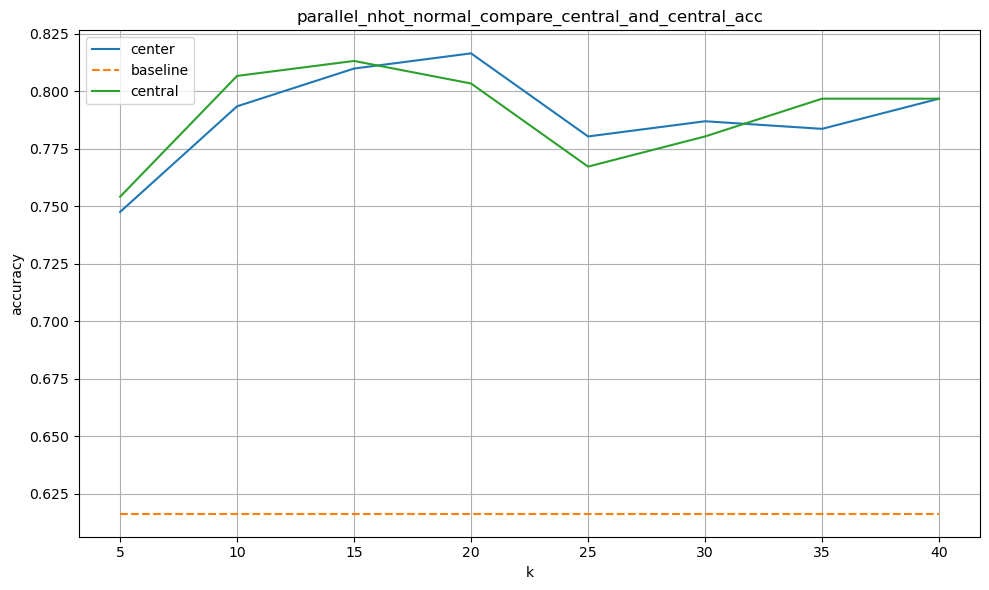

In [11]:
# Accuracy
result_dict = {}
result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['center'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]
result_dict['baseline'] = [raw_result_file['FA'][5]['baseline_acc']]*len(ks)

result_file = f'./parallel/nhot_normal/central_vector/0.99_0.99/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['central'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_nhot_normal_compare_central_and_central_acc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


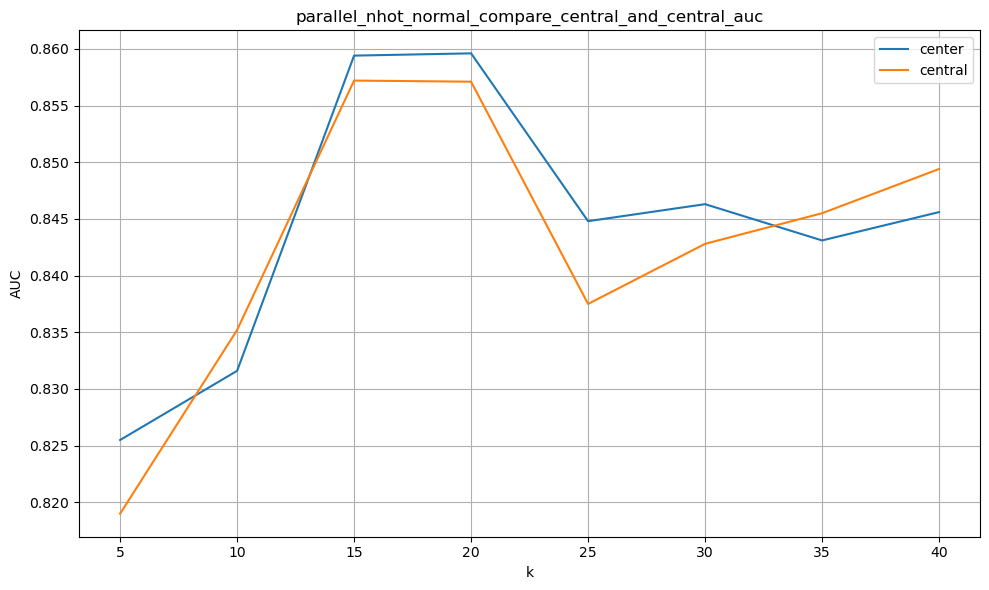

In [12]:
# AUC
result_dict = {}
result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['center'] = [raw_result_file['FA'][k]['auc'] for k in ks]

result_file = f'./parallel/nhot_normal/central_vector/0.99_0.99/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['central'] = [raw_result_file['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_nhot_normal_compare_central_and_central_auc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


### Label criteria 1 vs. 3 vs. 5

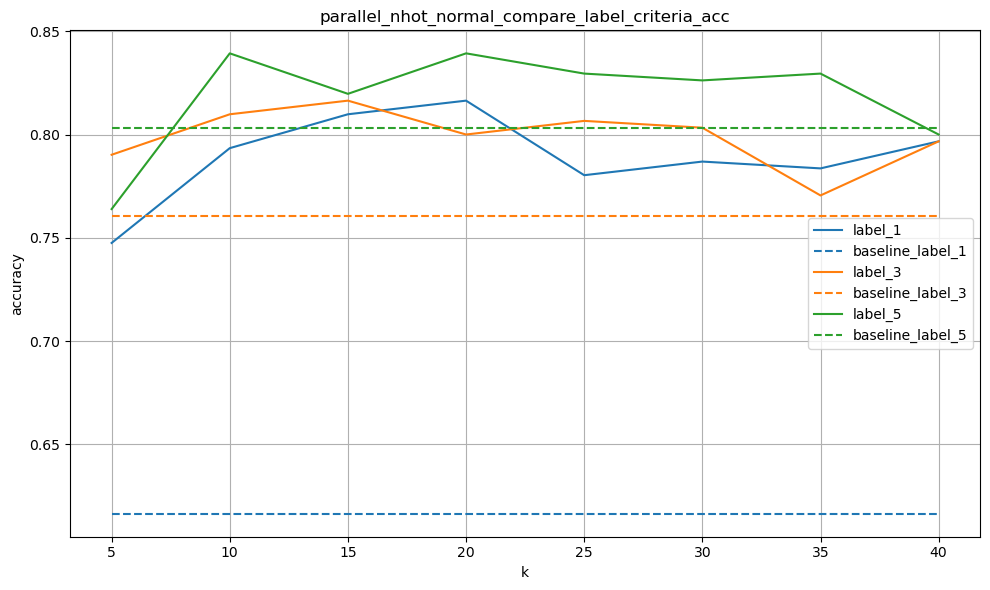

In [13]:
# Accuracy
result_dict = {}
result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['label_1'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]
result_dict['baseline_label_1'] = [raw_result_file['FA'][5]['baseline_acc']]*len(ks)

result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_3/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['label_3'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]
result_dict['baseline_label_3'] = [raw_result_file['FA'][5]['baseline_acc']]*len(ks)

result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_5/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['label_5'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]
result_dict['baseline_label_5'] = [raw_result_file['FA'][5]['baseline_acc']]*len(ks)

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_nhot_normal_compare_label_criteria_acc'
save_dir = './graphs/parallel/'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


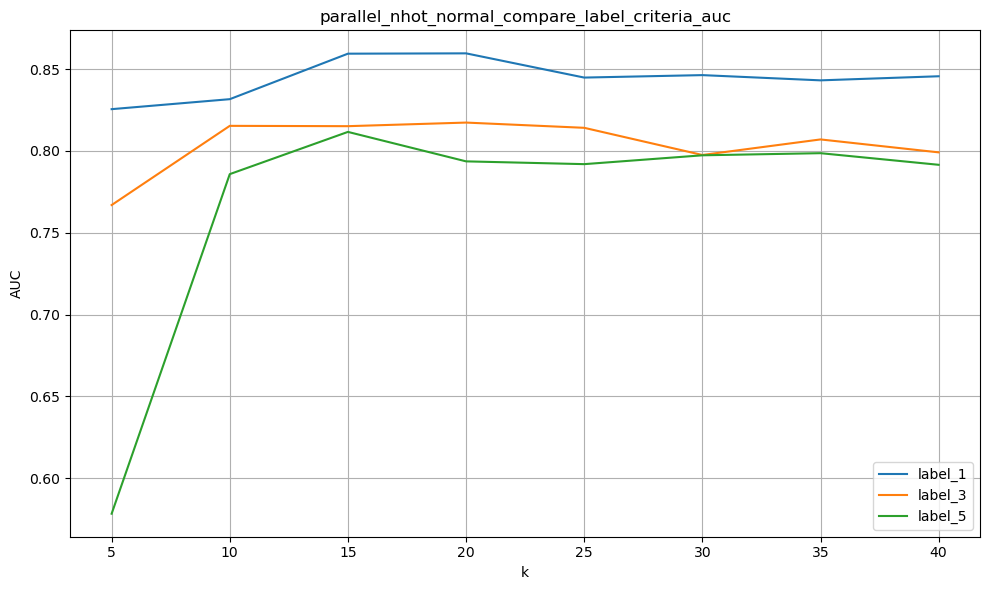

In [14]:
# AUC
result_dict = {}
result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_1/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['label_1'] = [raw_result_file['FA'][k]['auc'] for k in ks]

result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_3/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['label_3'] = [raw_result_file['FA'][k]['auc'] for k in ks]

result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_5/result.txt'

raw_result_file = read_result_file(result_file)
result_dict['label_5'] = [raw_result_file['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_nhot_normal_compare_label_criteria_auc'
save_dir = './graphs/parallel/'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)


### Sequential vs. Parallel (Label 1)

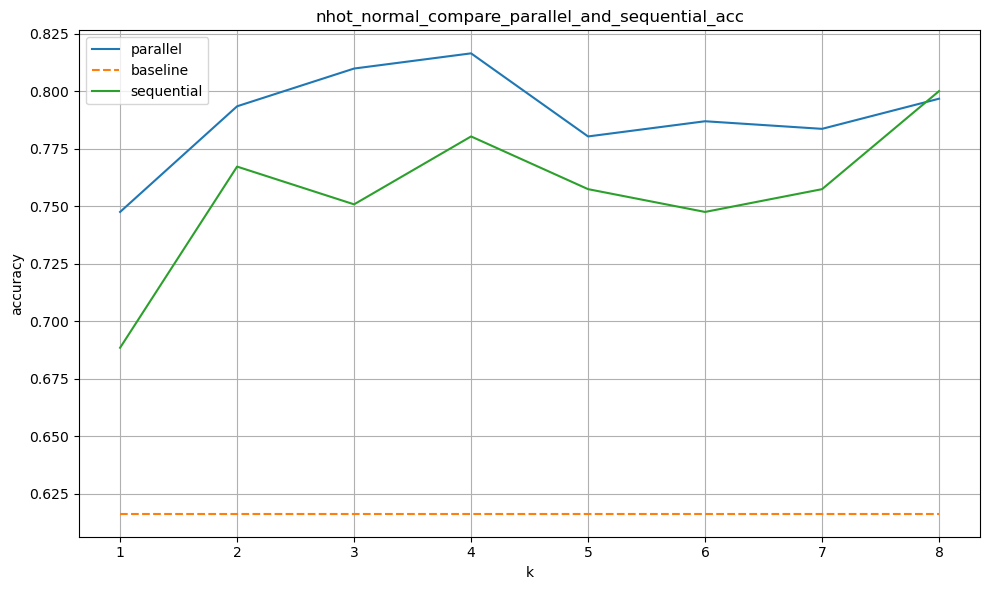

In [19]:
# Accuracy
result_dict = {}
result_file = f'./parallel/nhot_normal/center_vector/0.99_0.99/label_criteria_1/result.txt'

ks = [5, 10, 15, 20, 25, 30, 35, 40]
raw_result_file = read_result_file(result_file)
result_dict['parallel'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]
result_dict['baseline'] = [raw_result_file['FA'][5]['baseline_acc']]*len(ks)

result_file = f'./sequential/nhot_normal/center_vector/0.99_0.99/label_criteria_1/result.txt'

ks = list(range(1, 9))
raw_result_file = read_result_file(result_file)
result_dict['sequential'] = [raw_result_file['FA'][k]['accuracy'] for k in ks]

xlabel = 'k'
ylabel = 'accuracy'
title = 'nhot_normal_compare_parallel_and_sequential_acc'
save_dir = './graphs/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)
